In [1]:
# Run in conda ibiz environment
import torch
import numpy as np
import pandas as pd
import xarray as xr
import os
import pyproj

import importlib
import preprocess_radargrams_configs
importlib.reload(preprocess_radargrams_configs)

<module 'preprocess_radargrams_configs' from '/Users/kim.bente/Code/RadarCLIP/preprocess_radargrams_configs.py'>

In [2]:
# location of tar file
# NOTE: Start with 2016 data, as it is more recent and has better coverage
from preprocess_radargrams_configs import PATH_2016_AN_UTIG_ER2HI1B, PATH_2016_AN_UTIG_ER2HI2, CODE_1B, CODE_2
PATH_2016_AN_UTIG_ER2HI1B_folder = os.path.join(PATH_2016_AN_UTIG_ER2HI1B, "2016_AN_UTIG.ER2HI1B")

# Extract the list of .nc files in the folder
list_of_nc_files_2016_UTIG = [
    f for f in os.listdir(PATH_2016_AN_UTIG_ER2HI1B_folder) 
    if f.endswith(".nc")
    ]

list_of_nc_files_2016_UTIG_full_paths = [
    os.path.join(PATH_2016_AN_UTIG_ER2HI1B_folder, f)
    for f in os.listdir(PATH_2016_AN_UTIG_ER2HI1B_folder)
    if f.endswith(".nc")
]

# Proprocessing pipeline for radar data

## Steps
- Start from one image first
- Extract location of bed 
- crop IBIZ 
- Have a fixed scale
- Combine with bed picks

# Acronyms
- ER2HI1B - EAGLE Radar (?!) - HiCARS - Level 1B data
- ER2HI2 - EAGLE Radar (?!) - HiCARS - Level 2 data

- 2016 refers to the 2016/17 season so Jan 2017 is part of it

In [3]:
path_to_a_radargram = list_of_nc_files_2016_UTIG_full_paths[0]

radargram_ds = xr.open_dataset(path_to_a_radargram)
print("Granule ID:", radargram_ds.granule_id)
radargram_ds

Granule ID: ER2HI1B_2017024_TOT1_JKB2r_X19a_000


<xarray.Dataset> Size: 103MB
Dimensions:              (fasttime_dim: 3200, time: 4000)
Coordinates:
  * time                 (time) datetime64[ns] 32kB 2017-01-24T07:55:32.56640...
Dimensions without coordinates: fasttime_dim
Data variables:
    fasttime             (fasttime_dim) float32 13kB ...
    lat                  (time) float32 16kB ...
    lon                  (time) float32 16kB ...
    altitude             (time) float32 16kB ...
    pitch                (time) float32 16kB ...
    roll                 (time) float32 16kB ...
    heading              (time) float32 16kB ...
    amplitude_low_gain   (time, fasttime_dim) float32 51MB ...
    amplitude_high_gain  (time, fasttime_dim) float32 51MB ...
Attributes: (12/27)
    featureType:          timeSeries
    location:             C-GJKB
    source:               airborne ice penetrating radar
    data_version:         JUN292018
    netcdf_version:       4.1.2 of Apr 12 2011 15:15:12 $
    positioning:          transect based Ashtech CA GG24 reciever (no orrieta...
    ...                   ...
    rfparams:             RF PARAMETERS\nCenter Frequency: 60 MHz\nCenter Wav...
    digital:              DIGITAL PARAMETERS\nRecord duration: 64 microsecond...
    TX-record_offset:     Transmit delay from record start: 2.550 microseconds\n
    antenna:              ANTENNA PARAMETERS:\nPlatform: C-GJKB DC-3T aircraf...
    processing:           PROCESSING PARAMETERS\nMode name: pik1\nGoal: emula...
    references:           Peters, M.E., D.D. Blankenship, S.P. Carter, D.A. Y...

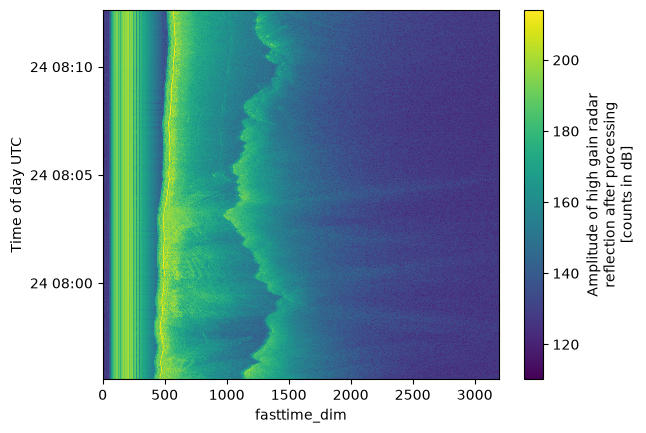

In [4]:
radargram_ds
# high gain more relevant for bed detection, low gain more relevant for surface detection
radargram_ds["amplitude_high_gain"].plot()

# Find matching bed pick

Granule ID: ER2HI1B_2017024_TOT1_JKB2r_X19a_000

## Construct full path from info we already have 

In [5]:
radargram_grandule_id_L2 = radargram_ds.granule_id[:5] + "2" + radargram_ds.granule_id[7:]
radargram_grandule_id_L2_cropped = radargram_grandule_id_L2[:-3]

PATH_L1B = PATH_2016_AN_UTIG_ER2HI2 + "/" + radargram_grandule_id_L2_cropped + "icethk.txt"
print(PATH_L1B)
# print("/Users/kim.bente/Documents/ANT_QGIS/AADC-DATA/AAS_4346_EAGLE_ICECAP_LEVEL2_AEROGEOPHYSICS/EAGLE-2015-2016-Level2/Level2/2016_AN_UTIG.ER2HI2/ER2HI2_2017024_TOT1_JKB2r_X19a_icethk.txt")

/Users/kim.bente/Documents/ANT_QGIS/AADC-DATA/AAS_4346_EAGLE_ICECAP_LEVEL2_AEROGEOPHYSICS/EAGLE-2015-2016-Level2/Level2/2016_AN_UTIG.ER2HI2/ER2HI2_2017024_TOT1_JKB2r_X19a_icethk.txt


In [6]:
# print the header lines from the L1B text file
with open(PATH_L1B, "r") as f:
    header_lines = [line for line in f if line.startswith("#")]

for line in header_lines:
    print(line, end = "")

# 2016_AN_UTIG ER2HI2 data format
# EAGLE HiCARS 2 L2 Geolocated Ice Thickness
# 
# Field 1: Year (UTC)
# Field 2: Day for year (UTC)
# Field 3: Second of day (UTC)
# Field 4: Longitude (decimal degrees; WGS-84)
# Field 5: Latitude (decimal degrees; WGS-84)
# Field 6: Radar Derived Ice Thickness (meters) (using dielectric of ice of 3.15 and no firn correction)
# Field 7: Radar Derived Surface Range (meters)
# Field 8: Radar Derived Bed Elevation (meters; WGS-84)
# Field 9: Radar Derived Surface Elevation (meters; WGS-84)
# Field 10: Bed reflection coefficient @ 60 MHz (dB wrt perfect reflector; NO ICE LOSS ACCOUNTING)
# Field 11: Surface reflection coefficient @ 60 MHz (dB wrt perfect reflector)
# Field 12: Roll (right wing down positive, degrees)
# 
# Input_data: ER2HI1B
# Input_data: EPUTN1B
# 
# Processing: EVA custom software
# 
# Datum: WGS-84 ellipsoid; ITRF 2008
# 
# Line_name: TOT1/JKB2r/X19a
# Flight: ICP8/F08
# Aircraft: AIRCRAFT
# Aircraft: DC-3T
# 
# Support: NSF 1543452; A

In [7]:
# grab last line for the column headers
col_names = header_lines[-1].lstrip("#").split()
print(col_names)

# now import the data into a pandas dataframe, skipping the header lines, but adding the column names from the last header line
l2_df = pd.read_csv(
    PATH_L1B,
    sep = r"\s+",           # whitespace-delimited (handles single or multiple spaces)
    comment = "#",          # skips any line starting with '#'
    header = None, 
    names = col_names,
)

l2_df.head()

['YEAR', 'DOY', 'SOD', 'LON', 'LAT', 'THK', 'SRF_RNG', 'BED_ELEVATION', 'SURFACE_ELEVATION', 'PARTIAL_BED_REFLECT', 'SRF_REFLECT', 'AIRCRAFT_ROLL']


,YEAR,DOY,SOD,LON,LAT,THK,SRF_RNG,BED_ELEVATION,SURFACE_ELEVATION,PARTIAL_BED_REFLECT,SRF_REFLECT,AIRCRAFT_ROLL
0,2017,24,28532.5655,113.872598,-67.610099,1249.84,1029.35,-768.33,481.51,-58.69,-33.18,-9999.0
1,2017,24,28532.8212,113.873047,-67.610024,1244.53,999.59,-733.12,511.41,-57.32,-34.69,-9999.0
2,2017,24,28533.0771,113.873496,-67.609949,1204.04,1002.24,-695.16,508.88,-59.32,-31.16,-9999.0
3,2017,24,28533.3339,113.873947,-67.609874,1205.95,997.76,-692.50,513.45,-55.82,-34.47,-9999.0
4,2017,24,28533.5894,113.874396,-67.609800,1192.47,1001.67,-682.83,509.64,-57.73,-31.19,-9999.0


In [8]:
# summary statistics
l2_df.describe()

,YEAR,DOY,SOD,LON,LAT,THK,SRF_RNG,BED_ELEVATION,SURFACE_ELEVATION,PARTIAL_BED_REFLECT,SRF_REFLECT,AIRCRAFT_ROLL
count,6408.0,6408.0,6408.000000,6408.000000,6408.000000,5882.000000,6408.000000,5881.000000,6408.000000,5709.000000,6388.000000,6408.0
mean,2017.0,24.0,29353.726173,115.294789,-67.354186,1113.753171,1249.826094,-869.162600,247.244257,-56.741505,-13.283707,-9999.0
std,0.0,0.0,474.209049,0.815272,0.148905,226.102440,132.323492,195.007019,136.886577,7.899282,4.247479,0.0
min,2017.0,24.0,28532.565500,113.872598,-67.610099,643.490000,997.760000,-1995.860000,83.880000,-80.760000,-35.610000,-9999.0
25%,2017.0,24.0,28943.144600,114.589418,-67.483058,951.505000,1099.885000,-1001.810000,125.242500,-62.060000,-14.892500,-9999.0
50%,2017.0,24.0,29353.725100,115.301045,-67.356016,1065.705000,1286.185000,-844.510000,205.265000,-58.330000,-12.390000,-9999.0
75%,2017.0,24.0,29764.307325,116.001780,-67.225840,1274.660000,1368.260000,-714.840000,400.442500,-52.010000,-10.600000,-9999.0
max,2017.0,24.0,30174.894000,116.695862,-67.092778,2108.640000,1413.170000,-414.950000,513.450000,-26.330000,-3.160000,-9999.0


## Convert to Polar Stereographic

In [9]:
# This is how projections work. check through tool
lonlat_to_polarstereo = pyproj.Transformer.from_crs(crs_from = pyproj.CRS("epsg:4326"),
                                                    crs_to = pyproj.CRS("epsg:3031"),
                                                    always_xy = True) # xy order convention

# Pass lon and lat columns, returns x and y columns in polar stereographic coordinates
x_array, y_array = lonlat_to_polarstereo.transform(l2_df["LON"], l2_df["LAT"])

l2_df["X"] = x_array
l2_df["Y"] = y_array

In [10]:
# Calculate the distance between each point and the next point in the dataframe, using the X and Y columns
distance_to_next = ((l2_df["X"].shift(-1) - l2_df["X"])**2 + (l2_df["Y"].shift(-1) - l2_df["Y"])**2)**0.5
print("Distance to next point in meters:")
print(distance_to_next.describe())

Distance to next point in meters:
count    6407.000000
mean       21.223165
std         0.161063
min        20.764658
25%        21.120740
50%        21.206816
75%        21.292548
max        22.057379
dtype: float64


# Join

Join additional info from L2 onto L1B. This may include:
- bed elevation (subtract bed elevation + flight altitude from L1B to get bed elevation)
    - unclear about surface range
- PARTIAL_BED_REFLECT # Field 10: Bed reflection coefficient @ 60 MHz (dB wrt perfect reflector; NO ICE LOSS ACCOUNTING)
- SRF_REFLECT # Field 11: Surface reflection coefficient @ 60 MHz (dB wrt perfect reflector)

Future:
- Use YEAR and DOY to check!

# Match via LON LAT

- L1B data is float32
- L2 data is float64. When we simply convert thus to float32 we match rather well

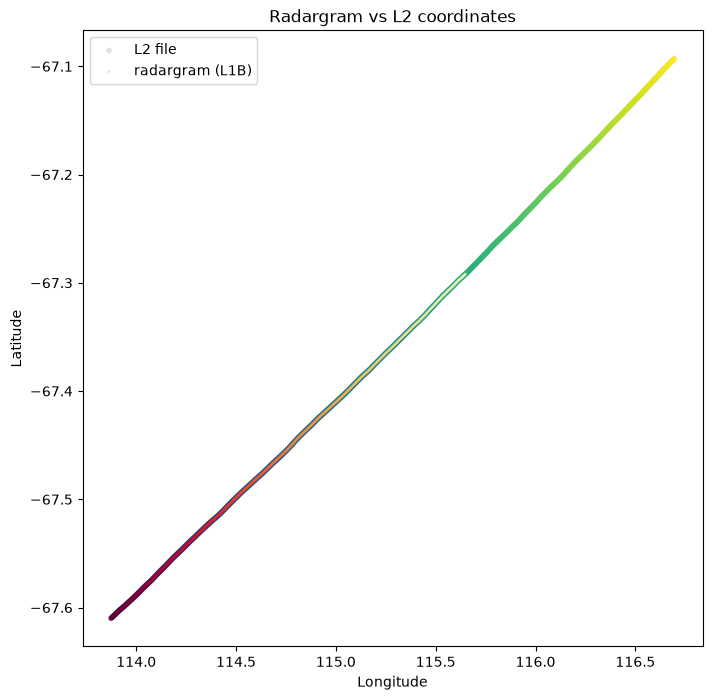

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))


ax.scatter(l2_df["LON"].values, l2_df["LAT"].values, 
           s = 9, alpha = 0.1, label = "L2 file", c = l2_df.index, cmap = "viridis")
ax.scatter(radargram_ds["lon"].values, radargram_ds["lat"].values, 
           s = 1, alpha = 0.1, label = "radargram (L1B)", c = np.arange(radargram_ds.time.size), cmap = "YlOrRd_r")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.set_title("Radargram vs L2 coordinates")
plt.show()

# Join

In [12]:
from scipy.spatial import cKDTree

# Use consistent dtype (float64) for both — don't force float32
radar_lon = radargram_ds["lon"].values.astype(np.float64)
radar_lat = radargram_ds["lat"].values.astype(np.float64)

l2_lon = l2_df["LON"].values.astype(np.float64)
l2_lat = l2_df["LAT"].values.astype(np.float64)

radar_coords = np.column_stack([radar_lon, radar_lat])
l2_coords = np.column_stack([l2_lon, l2_lat])

# Build tree on l2_df (the side we're pulling matches from)
tree = cKDTree(l2_coords)
tol = 1e-5  # degrees; tune to your data's actual precision/spacing

distances, indices = tree.query(radar_coords, distance_upper_bound=tol)

# distances == inf / indices == len(l2_coords) means "no match found"
has_match = distances < tol

# indices is len(radargram_ds) long, aligned to radar order
# invalid indices point out-of-bounds, so clip/mask them before indexing l2_df
safe_indices = np.where(has_match, indices, 0)  # placeholder for unmatched rows

matched_l2_subset = l2_df.iloc[safe_indices].reset_index(drop=True)

# Null out rows that didn't actually match
matched_l2_subset.loc[~has_match] = np.nan

print(f"Matched: {has_match.sum()} / {len(radar_coords)}")

# Select columns I want to transfer
selected_cols = ["THK", "BED_ELEVATION", "SURFACE_ELEVATION", "PARTIAL_BED_REFLECT", "SRF_REFLECT"]

for col in selected_cols:
    # along time dim
    radargram_ds[f"l2_{col}"] = ("time", matched_l2_subset[col].values)

del tree

Matched: 4000 / 4000


## Process L1B - Convert fasttime to meters

- Fasttime 3200 x Time 4000
- fasttime is 2-way travel time in µseconds

In [13]:
print("Fasttime units:")
print(radargram_ds.fasttime.long_name)
print()
print("Amplitude high gain units:")
print(radargram_ds.amplitude_high_gain.units)
print()
print(radargram_ds.amplitude_high_gain)
 # counts in dB

Fasttime units:
2-way travel time in µseconds

Amplitude high gain units:
counts in dB

<xarray.DataArray 'amplitude_high_gain' (time: 4000, fasttime_dim: 3200)> Size: 51MB
[12800000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 32kB 2017-01-24T07:55:32.566406250 ... 201...
Dimensions without coordinates: fasttime_dim
Attributes:
    units:      counts in dB
    long_name:  Amplitude of high gain radar reflection after processing


In [14]:
radargram_ds.fasttime.values

array([0.000e+00, 2.000e-02, 4.000e-02, ..., 6.394e+01, 6.396e+01,
       6.398e+01], shape=(3200,), dtype=float32)

# Attention

Conversion only works for ice not for air. 
For every column we have

In [ ]:
# speed of light in vacuum
c = 2.998e8  # m/s

# relative permittivity (epsilon_r) of ice (~ 3.15 is standard for glacial ice)
epsilon_ice = 3.15

# refractive index of ice
n = np.sqrt(epsilon_ice)

# speed of light in ice
v_ice = c / n 

# --- Air gap handling ---
# "free air content" = one-way distance from antenna to surface, in meters
air_gap_m = radargram_ds.altitude.values - radargram_ds.l2_SURFACE_ELEVATION.values  # plane altitude above surface

# Two-way travel time spent in air (round trip through air only)
air_twtt_seconds = (2 * air_gap_m) / c

# Convert fasttime (TWTT, in microseconds) to seconds
fasttime_in_seconds = radargram_ds.fasttime.values * 1e-6

# Subtract the air portion, leaving only the ice portion of the TWTT
# BROATCAST FASTTIME (1D) - AIR TWTT (1D) = ICE TWTT (2D)
ice_twtt_seconds = fasttime_in_seconds[:, None] - air_twtt_seconds[None, :]

# Convert remaining (ice-only) TWTT to depth in meters
# BELOW surface
depth_in_meters = v_ice * ice_twtt_seconds / 2

# --- NEW: piecewise one-way distance (air-speed before surface, ice-speed after) ---
in_air = fasttime_in_seconds[:, None] < air_twtt_seconds[None, :]

dist_air = c * fasttime_in_seconds[:, None] / 2
dist_ice = air_gap_m[None, :] + depth_in_meters

one_way_distance_m = np.where(in_air, dist_air, dist_ice)

elevation_m = radargram_ds.altitude.values[None, :] - one_way_distance_m

# Parts

In [15]:
# speed of light in vacuum
c = 2.998e8  # m/s

# relative permittivity (epsilon_r) of ice (~ 3.15 is standard for glacial ice)
epsilon_ice = 3.15

# refractive index of ice
n = np.sqrt(epsilon_ice)

# speed of light in ice
v_ice = c / n 

# --- Air gap handling ---
# "free air content" = one-way distance from antenna to surface, in meters
air_gap_m = radargram_ds.altitude.values - radargram_ds.l2_SURFACE_ELEVATION.values  # plane altitude above surface

# Two-way travel time spent in air (round trip through air only, given air gap in meters and speed of light in vacuum)
# Maybe 10% of time air travel
air_twtt_seconds = (2 * air_gap_m) / c

# Convert fasttime (TWTT, in microseconds) to seconds
fasttime_in_seconds = radargram_ds.fasttime.values * 1e-6

# Subtract the air portion, leaving only the ice portion of the TWTT
# fasttime_in_seconds is a column vector (y-axis), air_twtt_seconds is a row vector (x-axis), so we can broadcast the subtraction to get a 2D array of ice TWTT values
# NOTE: negative values mean time still in air, so we can mask those out later if needed
ice_twtt_seconds = fasttime_in_seconds.ravel()[:, np.newaxis] - air_twtt_seconds.ravel()[np.newaxis, :]

# --- Mask: True where sample is still in air (before surface return) ---
in_air_mask = ice_twtt_seconds < 0

# Container
one_way_distance_m = np.empty_like(ice_twtt_seconds)

# Fill air bins only: one way distance from altitude
one_way_distance_m[in_air_mask] = c * fasttime_in_seconds[:, np.newaxis].repeat(ice_twtt_seconds.shape[1], axis = 1)[in_air_mask] / 2

# Fill ice bins only
# Note: Maybe use cell atop
one_way_distance_m[~ in_air_mask] = (air_gap_m[np.newaxis, :] + v_ice * ice_twtt_seconds / 2)[~ in_air_mask]

In [ ]:
one_way_distance_m

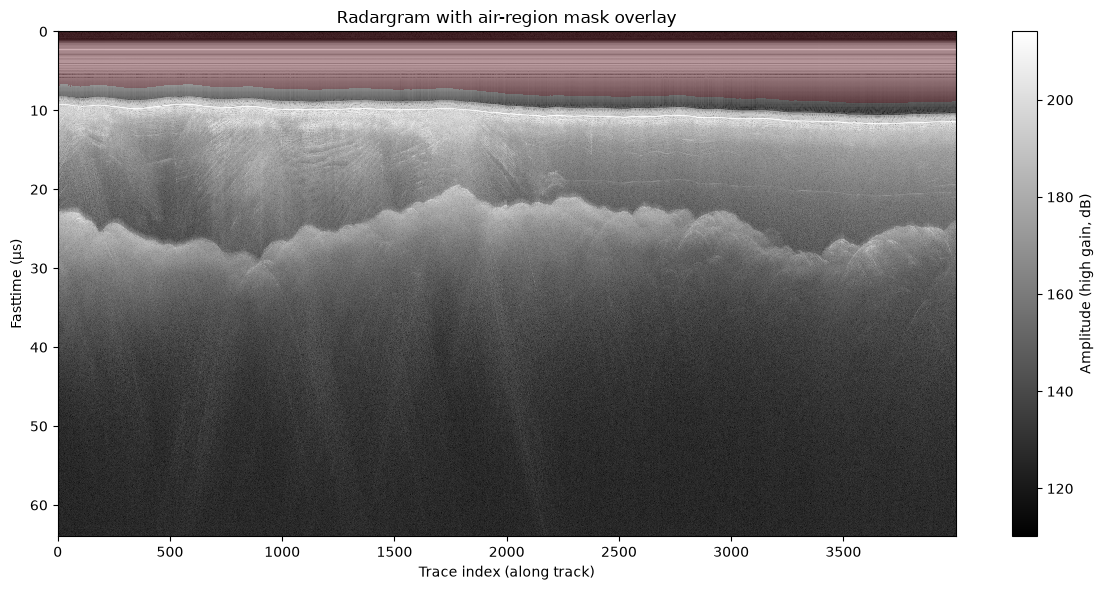

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

# amplitude is (time, fasttime_dim) -> transpose to (fasttime_dim, time) for pcolormesh's (Y, X) convention
amplitude = radargram_ds["amplitude_high_gain"].values.T  # now shape (3200, 4000)
fasttime = radargram_ds.fasttime.values                   # shape (3200,)
trace_idx = np.arange(amplitude.shape[1])                 # now correctly length 4000

mesh = ax.pcolormesh(trace_idx, fasttime, amplitude, shading = "auto", cmap = "gray")
fig.colorbar(mesh, ax=ax, label="Amplitude (high gain, dB)")

# Overlay mask — also needs the same transpose, since in_air_mask was built as (n_fasttime, n_traces)
mask_overlay = np.where(in_air_mask, 1, np.nan)  # in_air_mask should already be (fasttime, time) shaped
ax.pcolormesh(trace_idx, fasttime, mask_overlay, shading = "auto", cmap = "Reds", alpha = 0.3, vmin= 0, vmax = 1)

ax.set_xlabel("Trace index (along track)")
ax.set_ylabel("Fasttime (µs)")
ax.set_title("Radargram with air-region mask overlay")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
print("in_air_mask shape:", in_air_mask.shape)
print("amplitude shape:", amplitude.shape)
print("Number of True (in-air) cells:", in_air_mask.sum())
print("Total cells:", in_air_mask.size)
print("Fraction in air:", in_air_mask.sum() / in_air_mask.size)

in_air_mask shape: (3200, 4000)
amplitude shape: (3200, 4000)
Number of True (in-air) cells: 1568733
Total cells: 12800000
Fraction in air: 0.122557265625


In [ ]:
air_twtt_seconds[0] / fasttime_in_seconds[-1]

In [ ]:
air_twtt_seconds

In [ ]:
air_twtt_seconds[None, :]

In [ ]:
radargram_ds.altitude

In [ ]:
def fasttime_to_depth(fasttime_sec, altitude, c = 3e8, v_ice = v_ice):
    """
    fasttime_sec: 1D array, shape (fasttime_dim,) — two-way travel time in seconds
    altitude: scalar, aircraft altitude above surface for this trace (meters)
    Returns: depth below the ice surface (meters); negative values = above surface (in air)
    """
    t_surface = 2 * altitude / c
    depth = np.where(
        fasttime_sec <= t_surface,
        (c * fasttime_sec) / 2 - altitude,              # in air: height above surface (negative depth)
        (v_ice * (fasttime_sec - t_surface)) / 2         # in ice: depth below surface
    )
    return depth

In [ ]:
def fasttime_to_depth(fasttime_sec, altitude, c = 3e8, v_ice = v_ice):
    """
    fasttime_sec: 1D array, shape (fasttime_dim,) — two-way travel time in seconds
    altitude: scalar, aircraft altitude above surface for this trace (meters)
    Returns: depth below the ice surface (meters); negative values = above surface (in air)
    """
    t_surface = 2 * altitude / c
    depth = np.where(
        fasttime_sec <= t_surface,
        (c * fasttime_sec) / 2 - altitude,              # in air: height above surface (negative depth)
        (v_ice * (fasttime_sec - t_surface)) / 2         # in ice: depth below surface
    )
    return depth

# Questions:
How close are the picks? 
Can we match them with the radar data purely based in lon lat?
use reflectivity and other for correlation analysis (after) or also for processing?
Aircraft height is not in the L2 dataset.

Off-set to fix aircraft altitude...

Output:
256 pixels x 256 picels
256 x 20 m = 5 km around


In [ ]:
l2_df.LON

In [ ]:
np.argsort(radargram_ds.lat.values)[:3]


In [ ]:
print(radargram_ds.lat.values[0:3])
print(radargram_ds.lon.values[0:3])